 # EDA (Exploratory Data Analysis)

In [93]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns


In [94]:
df = pd.read_csv("../data/fraudTrain.csv", sep=",") # Importation des données

In [95]:
df.sample(10) # Affichage de 10 lignes aléatoire

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
639335,639335,2019-09-29 09:33:10,4355790796238264643,fraud_Kris-Padberg,shopping_pos,3.78,Tanner,Davis,M,2632 Stevens Light Apt. 213,...,39.8153,-91.2627,1656,Exhibition designer,1969-08-04,b034321a17af30d47390337c8df8ce40,1348911190,40.269464,-91.197989,0
537146,537146,2019-08-18 17:41:30,3596217206093829,fraud_Daugherty-Thompson,food_dining,5.17,Sara,Ramirez,F,23843 Scott Island,...,40.8626,-91.9534,888,Camera operator,1988-03-25,916c2cd1e6109cf6b80adec6ef6ea3e3,1345311690,40.063171,-92.123178,0
942566,942566,2020-01-11 20:36:55,630451534402,fraud_Zboncak Ltd,food_dining,42.14,Rachel,Daniels,F,561 Little Plain Apt. 738,...,46.3535,-86.6345,765,Immunologist,1972-06-12,190dca0dfeccc071e11c1de5c89d5e3e,1357936615,46.040499,-87.412555,0
980829,980829,2020-02-02 18:10:31,213124978348176,fraud_Goldner-Lemke,entertainment,263.66,Steven,Arnold,M,079 Chelsea Rest,...,42.3200,-78.0943,1766,Mechanical engineer,1962-06-04,53260d3315bbb597c5976b8453df0fe1,1359828631,41.674059,-78.947949,0
489459,489459,2019-08-02 06:44:19,4048508450704760,"fraud_Casper, Hand and Zulauf",grocery_pos,113.17,Cheryl,Melton,F,5053 Bell Crescent Apt. 255,...,41.3660,-98.0054,1749,"Surveyor, mining",1973-05-07,c11a820e09d015ec2afe501d1dcadc7e,1343889859,40.847384,-98.673918,0
877572,877572,2019-12-21 21:23:54,3576021480694169,"fraud_Schumm, McLaughlin and Carter",food_dining,4.42,Dawn,Gray,F,9486 Joel Common Suite 554,...,39.1329,-95.7023,163415,Secondary school teacher,2004-12-30,b3bc5b66ed19feac91bdc6d42c883823,1356125034,38.741495,-95.806306,0
342230,342230,2019-06-10 10:33:13,3565423334076143,fraud_Friesen Inc,shopping_pos,6.27,Nathan,Thomas,M,4923 Campbell Pines Suite 717,...,38.9763,-87.3667,4081,Energy engineer,1938-03-15,cfda9439cb2f2c3c2302032d5d175191,1339324393,38.383032,-87.146255,0
131556,131556,2019-03-13 17:25:06,30131826429364,fraud_Lynch-Wisozk,home,7.35,Brianna,Foley,F,57256 Raymond Ports,...,35.9335,-84.1481,391389,"Designer, industrial/product",1994-04-22,ee10486882840b4445d7f007ed3e24f3,1331659506,36.699377,-84.635690,0
600662,600662,2019-09-12 10:51:30,3521815216091574,fraud_Bernhard Inc,gas_transport,65.45,Wayne,Marsh,M,172 Leonard Island,...,39.7532,-105.6356,565,Mental health nurse,1978-08-27,fdae19f4400dafc259fc3642b489ec5b,1347447090,40.285777,-104.940226,0
141528,141528,2019-03-17 23:13:53,4428154703770710,fraud_Ernser-Lynch,food_dining,16.65,Brittany,Guerra,F,79209 Gary Dale,...,46.5901,-117.1692,761,Chief Marketing Officer,1943-06-30,e3b59e24f21727164609c4ebfd67aa59,1332026033,46.361633,-118.082728,0


In [96]:
df['is_fraud'].value_counts(normalize=True)

is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64

On constate qu'on a un dataset très deséquilibrer 0,005% de fraude

In [97]:
df.dtypes

Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

<Axes: ylabel='count'>

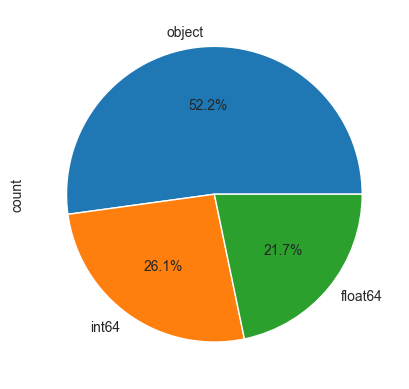

In [98]:
df.dtypes.value_counts().plot.pie(autopct='%1.1f%%')

On constate qu'il y a beaucoup de colonne de type object

In [99]:
print(df.duplicated().sum().sum())

0


In [100]:
df.describe(include="all")

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1296675,1.296675e+06,1296675,1296675,1.296675e+06,1296675,1296675,1296675,1296675,...,1.296675e+06,1.296675e+06,1.296675e+06,1296675,1296675,1296675,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
unique,NaN,1274791,NaN,693,14,NaN,352,481,2,983,...,NaN,NaN,NaN,494,968,1296675,NaN,NaN,NaN,NaN
top,NaN,2019-04-22 16:02:01,NaN,fraud_Kilback LLC,gas_transport,NaN,Christopher,Smith,F,864 Reynolds Plains,...,NaN,NaN,NaN,Film/video editor,1977-03-23,8f7c8e4ab7f25875d753b422917c98c9,NaN,NaN,NaN,NaN
freq,NaN,4,NaN,4403,131659,NaN,26669,28794,709863,3123,...,NaN,NaN,NaN,9779,5636,1,NaN,NaN,NaN,NaN
mean,6.483370e+05,NaN,4.171920e+17,NaN,NaN,7.035104e+01,NaN,NaN,NaN,NaN,...,3.853762e+01,-9.022634e+01,8.882444e+04,NaN,NaN,NaN,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,NaN,1.308806e+18,NaN,NaN,1.603160e+02,NaN,NaN,NaN,NaN,...,5.075808e+00,1.375908e+01,3.019564e+05,NaN,NaN,NaN,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,NaN,6.041621e+10,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,...,2.002710e+01,-1.656723e+02,2.300000e+01,NaN,NaN,NaN,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,NaN,1.800429e+14,NaN,NaN,9.650000e+00,NaN,NaN,NaN,NaN,...,3.462050e+01,-9.679800e+01,7.430000e+02,NaN,NaN,NaN,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,NaN,3.521417e+15,NaN,NaN,4.752000e+01,NaN,NaN,NaN,NaN,...,3.935430e+01,-8.747690e+01,2.456000e+03,NaN,NaN,NaN,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,NaN,4.642255e+15,NaN,NaN,8.314000e+01,NaN,NaN,NaN,NaN,...,4.194040e+01,-8.015800e+01,2.032800e+04,NaN,NaN,NaN,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00


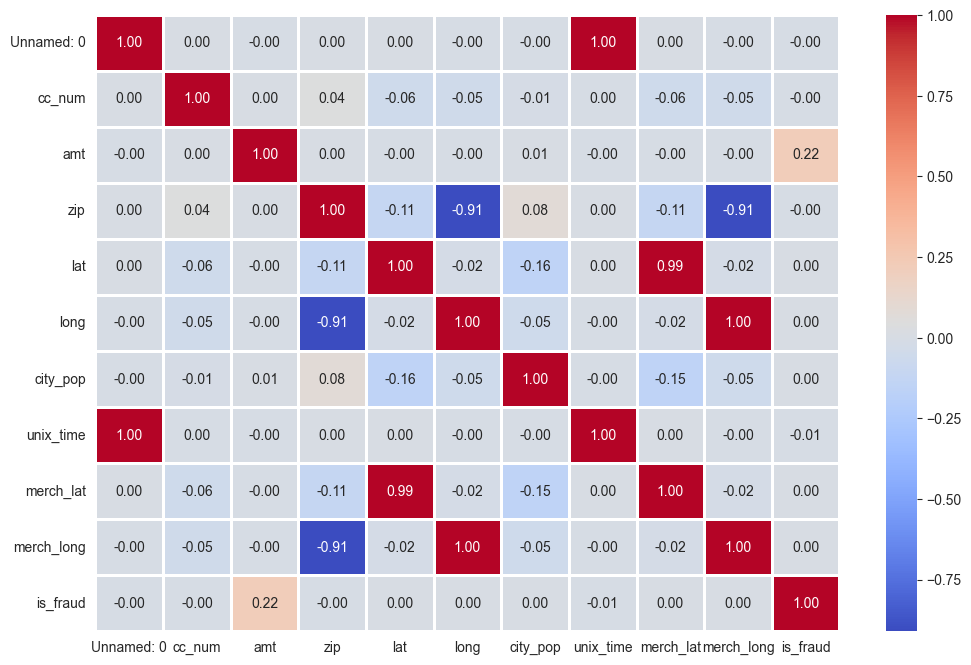

In [101]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
#kot = corr[(corr !=1.000) & ((corr >=0.4) | (corr <=(-0.2)))]
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=1,
            )
plt.show()

In [102]:
df.drop(["merch_lat","merch_long","lat","long",'Unnamed: 0','trans_num','cc_num','last','first'], axis=1, inplace=True)

Suppression des colonnes qui ne seront pas utilisés pour l'entrainement

In [103]:
df.describe(include='all')

,trans_date_trans_time,merchant,category,amt,gender,street,city,state,zip,city_pop,job,dob,unix_time,is_fraud
count,1296675,1296675,1296675,1.296675e+06,1296675,1296675,1296675,1296675,1.296675e+06,1.296675e+06,1296675,1296675,1.296675e+06,1.296675e+06
unique,1274791,693,14,NaN,2,983,894,51,NaN,NaN,494,968,NaN,NaN
top,2019-04-22 16:02:01,fraud_Kilback LLC,gas_transport,NaN,F,864 Reynolds Plains,Birmingham,TX,NaN,NaN,Film/video editor,1977-03-23,NaN,NaN
freq,4,4403,131659,NaN,709863,3123,5617,94876,NaN,NaN,9779,5636,NaN,NaN
mean,NaN,NaN,NaN,7.035104e+01,NaN,NaN,NaN,NaN,4.880067e+04,8.882444e+04,NaN,NaN,1.349244e+09,5.788652e-03
std,NaN,NaN,NaN,1.603160e+02,NaN,NaN,NaN,NaN,2.689322e+04,3.019564e+05,NaN,NaN,1.284128e+07,7.586269e-02
min,NaN,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,1.257000e+03,2.300000e+01,NaN,NaN,1.325376e+09,0.000000e+00
25%,NaN,NaN,NaN,9.650000e+00,NaN,NaN,NaN,NaN,2.623700e+04,7.430000e+02,NaN,NaN,1.338751e+09,0.000000e+00
50%,NaN,NaN,NaN,4.752000e+01,NaN,NaN,NaN,NaN,4.817400e+04,2.456000e+03,NaN,NaN,1.349250e+09,0.000000e+00
75%,NaN,NaN,NaN,8.314000e+01,NaN,NaN,NaN,NaN,7.204200e+04,2.032800e+04,NaN,NaN,1.359385e+09,0.000000e+00


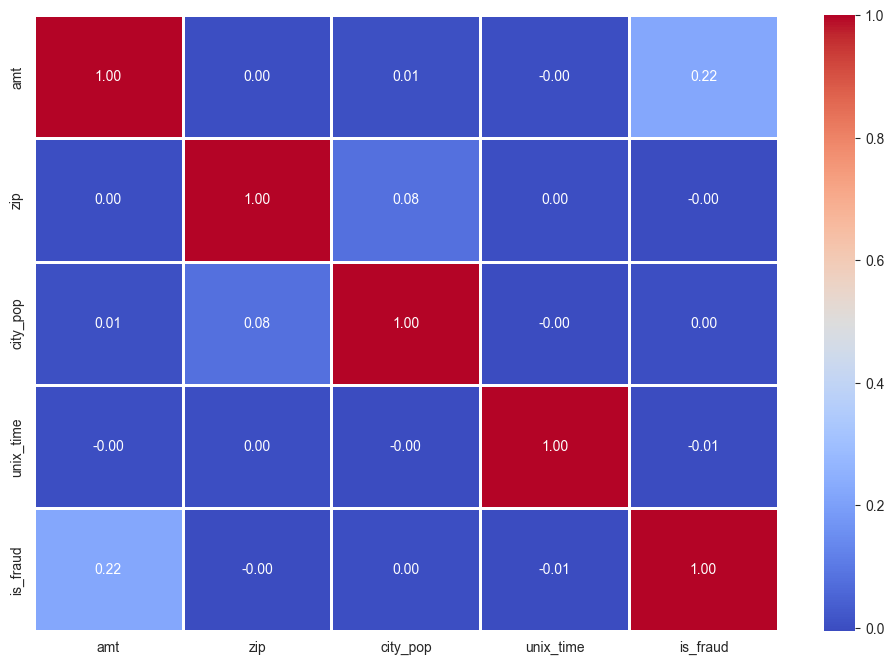

In [104]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=1,
            )
plt.show()

Pas de corrélation entre les colonnes numériques sélectionnée

In [105]:
df.sample(5)

,trans_date_trans_time,merchant,category,amt,gender,street,city,state,zip,city_pop,job,dob,unix_time,is_fraud
1076751,2020-03-23 11:27:01,fraud_Lemke-Gutmann,shopping_net,3.46,M,062 Poole Hollow Apt. 815,Deadwood,SD,57732,1979,Multimedia programmer,1970-03-13,1364038021,0
166449,2019-03-29 13:40:48,fraud_Pacocha-Bauch,shopping_pos,5.48,F,65417 Walsh Radial Suite 691,Saint Amant,LA,70774,10076,"Surveyor, rural practice",1977-12-16,1333028448,0
178566,2019-04-03 12:45:40,"fraud_Romaguera, Cruickshank and Greenholt",shopping_net,15.68,F,034 Kimberly Mountains,Brandon,FL,33510,79613,Environmental consultant,1978-11-30,1333457140,0
1002684,2020-02-15 22:20:06,fraud_Champlin and Sons,home,67.67,M,086 Pierce Cove,Pikesville,MD,21208,33917,Company secretary,1977-06-12,1360966806,0
1060947,2020-03-16 13:33:02,fraud_Eichmann-Kilback,home,14.71,F,2918 David Spurs,Georgetown,MN,56546,346,"Research officer, trade union",1976-12-14,1363440782,0


# Pretraitement

In [106]:
# Prétraitement
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler,LabelEncoder,OrdinalEncoder,OneHotEncoder
from datetime import datetime
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [107]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])
df['age_at_transaction'] = (df['trans_date_trans_time'] - df['dob']).dt.days / 365.25
df['age_at_transaction'] = df['age_at_transaction'].round(0).astype(int)
df['age_at_transaction']

0          31
1          41
2          57
3          52
4          33
           ..
1296670    59
1296671    41
1296672    53
1296673    40
1296674    25
Name: age_at_transaction, Length: 1296675, dtype: int64

<Axes: ylabel='Frequency'>

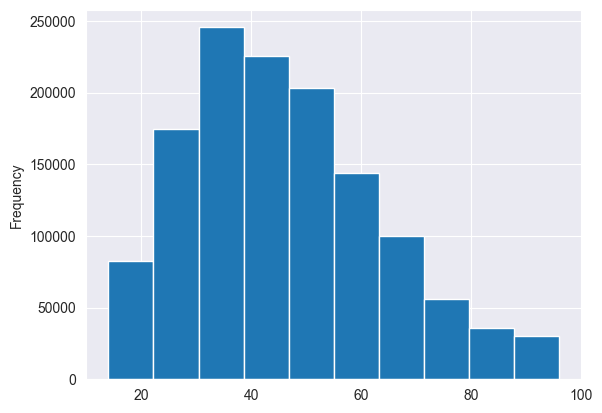

In [108]:
df['age_at_transaction'].plot(kind='hist')

On observe que la dataset est composé en frande partie de 30 à 50 ans

In [111]:
df.sample(4)

,trans_date_trans_time,merchant,category,amt,gender,street,city,state,zip,city_pop,job,dob,unix_time,is_fraud,age_at_transaction
847301,2019-12-15 02:20:20,fraud_Hermann-Gaylord,misc_pos,127.72,F,87665 Karen Mill Apt. 586,Fort Myers,FL,33967,224256,Paramedic,1985-08-29,1355538020,0,34
562222,2019-08-27 05:04:52,fraud_Block-Parisian,misc_net,122.39,M,3426 David Divide Suite 717,Burns Flat,OK,73624,2142,Politician's assistant,1976-06-30,1346043892,0,43
526267,2019-08-14 22:21:48,fraud_Fisher-Schowalter,shopping_net,1.71,F,4529 Cannon Alley,Center Point,WV,26339,255,Chief Executive Officer,1971-12-10,1344982908,0,48
1158190,2020-04-27 23:46:17,"fraud_Parker, Nolan and Trantow",entertainment,40.84,F,566 Megan Well,Brownville,NY,13615,1271,"Producer, radio",1958-08-14,1367106377,0,62


In [112]:
y = df["is_fraud"].astype(int)
X = df.drop(columns=["is_fraud"])

In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Découpage stratifié du dataset en X_train et X_test

In [114]:
#Importation de la classe TransactionDateTransformer pour le traitement de "age_at_transaction" et "trans_date_trans_time" dans les pipeline
from transformers_ML import TransactionDateTransformer

In [115]:
# Transformer personnalisé
date_transformer = TransactionDateTransformer()

numeric_features = ["amt","zip", "city_pop", "age_at_transaction","trans_date_trans_time_timestamp"]
categorical_features_non_ord = ["state", "city","gender","category","merchant","job"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_non_ord_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinay", OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1
    )) # Gere les categories inconnue
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat_non_ord", categorical_non_ord_transformer, categorical_features_non_ord),
    ],
    remainder="drop"
)

Création de pipeline pour automatiser la traitement des données

# Machine Learning

In [116]:
# Modèles de Machine Learning
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, auc,roc_auc_score,precision_recall_curve

In [117]:
model_xgb = XGBClassifier(
        # --- Accélération Matérielle ---
    tree_method='hist',             # Activation du GPU
    device='cuda:0',                # Activation du GPU
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=10,            # ratio 99% / 1%
    subsample=0.8,                  # Sous-échantillonnage des lignes
    colsample_bytree=0.8,           # Sous-échantillonnage des colonnes
    eval_metric='aucpr',            # Optimise pour la précision-rappel
    random_state=42
)

pipe = Pipeline(steps=[
    ("date_transform", date_transformer),
    ("preprocess", preprocessor),
    ("model", model_xgb)
])
# Création de la Pipeline pour le date_transformer,preprocessor et le model_xgb

Création du modéle XGBClassifier

In [118]:
pipe.fit(X_train, y_train)

,steps,"[('date_transform', ...), ('preprocess', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,trans_date_col,'trans_date_trans_time'
,dob_col,'dob'
,transformers,"[('num', ...), ('cat_non_ord', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None


Entrainement du modéle model_xgb

In [119]:
X_train

,trans_date_trans_time,merchant,category,amt,gender,street,city,state,zip,city_pop,job,dob,unix_time,age_at_transaction
509059,2019-08-09 03:13:27,"fraud_Stokes, Christiansen and Sipes",grocery_net,51.71,F,79472 Stevens Trace Apt. 120,Hannawa Falls,NY,13647,69,Chief Executive Officer,1991-06-05,1344482007,28
395295,2019-06-29 19:56:48,fraud_Effertz LLC,entertainment,13.78,F,554 Mcdonald Valley Apt. 539,Meridian,TX,76665,2526,Phytotherapist,1970-11-12,1340999808,49
536531,2019-08-18 14:42:20,fraud_Kris-Padberg,shopping_pos,961.26,F,7202 Jeffrey Mills,Conway,WA,98238,85,"Research officer, political party",1984-09-01,1345300940,35
271001,2019-05-13 21:27:46,fraud_Ratke and Sons,health_fitness,43.68,M,5758 Yates Center,Vinton,CA,96135,128,Education administrator,1966-02-21,1336944466,53
532788,2019-08-17 14:15:41,fraud_Upton PLC,entertainment,33.08,F,852 Thomas Well Suite 339,Owensville,MO,65066,6703,Naval architect,1998-05-20,1345212941,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125527,2019-03-10 21:06:15,"fraud_Effertz, Welch and Schowalter",entertainment,19.70,F,87665 Karen Mill Apt. 586,Fort Myers,FL,33967,224256,Paramedic,1985-08-29,1331413575,34
150047,2019-03-22 05:06:39,fraud_Pacocha-Bauch,shopping_pos,123.45,M,495 Fisher Throughway,Grand Junction,TN,38039,1804,Clothing/textile technologist,1974-10-15,1332392799,44
1151888,2020-04-25 18:11:52,fraud_Abernathy and Sons,food_dining,64.98,F,55363 Aaron Circle Suite 450,Lawn,PA,17041,213,Special educational needs teacher,1972-02-15,1366913512,48
547306,2019-08-22 14:59:38,fraud_Windler LLC,kids_pets,33.65,M,01479 Murray Circle,Matawan,NJ,7747,30770,Drilling engineer,1993-04-29,1345647578,26


In [120]:
y_pred = pipe.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9953
F1-score:  0.6759

Confusion matrix:
 [[256845    989]
 [   230   1271]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.56      0.85      0.68      1501

    accuracy                           1.00    259335
   macro avg       0.78      0.92      0.84    259335
weighted avg       1.00      1.00      1.00    259335



Le modéle detecte 85% des fraudes(Recall)

In [122]:
column_names = preprocessor.get_feature_names_out()
# 2. On crée la Series avec ces noms
feat_importances = pd.Series(model_xgb.feature_importances_, index=column_names).sort_values(ascending=False)
print(feat_importances)

num__amt                                0.557034
cat_non_ord__category                   0.193341
cat_non_ord__gender                     0.056132
num__age_at_transaction                 0.040215
num__city_pop                           0.028798
num__trans_date_trans_time_timestamp    0.026166
cat_non_ord__job                        0.022155
cat_non_ord__city                       0.021606
num__zip                                0.020428
cat_non_ord__state                      0.019749
cat_non_ord__merchant                   0.014376
dtype: float32


On vois si dessus l'importance des colonnes, amt représente 55% de performance

In [141]:
y_probs = pipe.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

pr_auc = auc(recall, precision)
print(f"pr_auc: {pr_auc:.2f}")

pr_auc: 0.83


Un PR AUC de 0.83 garantit que le modèle cible efficacement les fraudes tout en limitant les faux positifs

In [124]:
import joblib

# Sauvegarder sur le disque
joblib.dump(pipe, '../Models/model_fraude_xgboost_final_2.pkl')

print("Modèle complet sauvegardé sous 'model_fraude_xgboost_final.pkl'")

Modèle complet sauvegardé sous 'model_fraude_xgboost_final.pkl'


Rechercher des meilleures hyper parametre avec RandomizedSearchCV

In [125]:
from sklearn.metrics import make_scorer, average_precision_score
from sklearn.model_selection import RandomizedSearchCV
# Configuration de la validation croisée (essentiel pour le 1% de fraude)

# Définition de la grille de recherche
param_grid = {
    'model__max_depth': [3, 4, 5],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__n_estimators': [100, 200, 300],
    'model__scale_pos_weight': [10, 50, 99],
    'model__subsample': [0.8],
    'model__colsample_bytree': [0.8],
    'model__min_child_weight': [1, 5]
}

# Scoring axé sur la précision/rappel (AUPRC)
auprc_scorer = make_scorer(average_precision_score, response_method='predict_proba')
random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_grid,
    n_iter=30,                     # On limite à 30 combinaisons
    scoring=auprc_scorer,
    cv=5,
    verbose=2,
    n_jobs=-1,                      # Utilisation de tout les coeurs du processeur
    random_state=42
)

# Total fits : 30 itérations * 5 folds = 150 fits
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.8], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 4, ...], 'model__min_child_weight': [1, 5], ...}"
,n_iter,30
,scoring,make_scorer(a...redict_proba')
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [126]:
# Le meilleur modèle complet (avec preprocessing + meilleurs hyperparamètres)
best_pipeline = random_search.best_estimator_

# Afficher les meilleurs réglages
print("Meilleurs paramètres trouvés :", random_search.best_params_)

Meilleurs paramètres trouvés : {'model__subsample': 0.8, 'model__scale_pos_weight': 10, 'model__n_estimators': 300, 'model__min_child_weight': 5, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}


Meilleure paramètre pour le modèle model_xgb

In [127]:
# Evaluation du modele optimise
best_model = random_search.best_estimator_

y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

acc_best = accuracy_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)

print(f"Accuracy: {acc_best:.4f}")
print(f"F1-score: {f1_best:.4f}")

roc_auc_best = roc_auc_score(y_test, y_pred_proba_best)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_best)
pr_auc_best = auc(recall, precision)

print(f"ROC-AUC: {roc_auc_best:.4f}")
print(f"PR-AUC: {pr_auc_best:.4f}")

print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_best))
print("\nClassification report:\n", classification_report(y_test, y_pred_best))

Accuracy: 0.9953
F1-score: 0.6764
ROC-AUC: 0.9963
PR-AUC: 0.8294

Confusion matrix:
 [[256836    998]
 [   224   1277]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.56      0.85      0.68      1501

    accuracy                           1.00    259335
   macro avg       0.78      0.92      0.84    259335
weighted avg       1.00      1.00      1.00    259335



In [128]:
for i in np.arange(0.1, 1, 0.1):
    # 2. Appliquer le nouveau seuil de detection d'une fraude
    threshold = i
    y_pred_custom = (y_pred_proba_best >= threshold).astype(int)

    # 3. Afficher le nouveau rapport
    from sklearn.metrics import classification_report, confusion_matrix
    print(f"--- RAPPORT AVEC SEUIL {threshold:.1f} ---")
    print(classification_report(y_test, y_pred_custom))

--- RAPPORT AVEC SEUIL 0.1 ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    257834
           1       0.22      0.95      0.36      1501

    accuracy                           0.98    259335
   macro avg       0.61      0.97      0.67    259335
weighted avg       1.00      0.98      0.99    259335

--- RAPPORT AVEC SEUIL 0.2 ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    257834
           1       0.37      0.91      0.53      1501

    accuracy                           0.99    259335
   macro avg       0.69      0.95      0.76    259335
weighted avg       1.00      0.99      0.99    259335

--- RAPPORT AVEC SEUIL 0.3 ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    257834
           1       0.46      0.89      0.61      1501

    accuracy                           0.99    259335
   macro avg       0.73      0.94  

On peut ensuite ajuster le seuil de détection d'une fraude, le seuille de 0,4 ou 0,5 me semble pertinent pour garder un bon recall et precision

On teste un deuxieme modème Random forest

In [129]:
# Modele 2: Random Forest
model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight={0: 1, 1: 100},  # gere le desequilibre on donne 100 fois plus d'importance au fraude
    random_state=42,
    n_jobs=-1  # utilise tous les coeurs CPU
)

pipe_rf = Pipeline(steps=[
    ("date_transform", date_transformer),
    ("preprocess", preprocessor),
    ("model", model_rf)
])

pipe_rf.fit(X_train, y_train)

,steps,"[('date_transform', ...), ('preprocess', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,trans_date_col,'trans_date_trans_time'
,dob_col,'dob'
,transformers,"[('num', ...), ('cat_non_ord', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None


In [130]:
# Evaluation Random Forest
y_pred_rf = pipe_rf.predict(X_test)
y_pred_proba_rf = pipe_rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf) # Calcule acc_rf
f1_rf = f1_score(y_test, y_pred_rf) # Calcule f1_rf

print(f"Accuracy: {acc_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")

roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_rf)
pr_auc_rf = auc(recall, precision)

print(f"ROC-AUC: {roc_auc_rf:.4f}")
print(f"PR-AUC: {pr_auc_rf:.4f}")

print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.9907
F1-score: 0.5170
ROC-AUC: 0.9916
PR-AUC: 0.7316

Confusion matrix:
 [[255643   2191]
 [   214   1287]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    257834
           1       0.37      0.86      0.52      1501

    accuracy                           0.99    259335
   macro avg       0.68      0.92      0.76    259335
weighted avg       1.00      0.99      0.99    259335



Le modele detecte 86% des fraude mais qu'une fraude sur trois est vrai

In [131]:
# 1. Obtenir les probabilités au lieu des classes (0 ou 1)
# predict_proba renvoie deux colonnes : [probabilité de 0, probabilité de 1]

for i in np.arange(0.1, 1, 0.1):
    # 2. Appliquer le nouveau seuil de 0.3
    threshold = i
    y_pred_custom = (y_pred_proba_rf >= threshold).astype(int)

    # 3. Afficher le nouveau rapport
    from sklearn.metrics import classification_report, confusion_matrix
    print(f"--- RAPPORT AVEC SEUIL {threshold:.1f} ---")
    print(classification_report(y_test, y_pred_custom))

--- RAPPORT AVEC SEUIL 0.1 ---
              precision    recall  f1-score   support

           0       1.00      0.78      0.88    257834
           1       0.03      1.00      0.05      1501

    accuracy                           0.78    259335
   macro avg       0.51      0.89      0.46    259335
weighted avg       0.99      0.78      0.87    259335

--- RAPPORT AVEC SEUIL 0.2 ---
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    257834
           1       0.07      0.97      0.13      1501

    accuracy                           0.93    259335
   macro avg       0.54      0.95      0.55    259335
weighted avg       0.99      0.93      0.96    259335

--- RAPPORT AVEC SEUIL 0.3 ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    257834
           1       0.15      0.92      0.26      1501

    accuracy                           0.97    259335
   macro avg       0.57      0.95  

Avec un score de confiance de 0.7 est le plus adapter pour garder un bon score F1

In [132]:
# Sauvegarder sur le disque
joblib.dump(pipe, '../Models/model_rf_final.pkl')

print("Modèle complet sauvegardé sous 'model_rf_final.pkl'")

Modèle complet sauvegardé sous 'model_rf_final.pkl'


In [133]:
# Modele 3: Logistic Regression
model_lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1                     #Utilisation de tout les coeurs
)

pipe_lr = Pipeline(steps=[
    ("date_transform", date_transformer),
    ("preprocess", preprocessor),
    ("model", model_lr)
])

pipe_lr.fit(X_train, y_train) # Entrainement du modele LogisticRegression

,steps,"[('date_transform', ...), ('preprocess', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,trans_date_col,'trans_date_trans_time'
,dob_col,'dob'
,transformers,"[('num', ...), ('cat_non_ord', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None


In [134]:
# Evaluation Logistic Regression
y_pred_lr = pipe_lr.predict(X_test)
y_pred_proba_lr = pipe_lr.predict_proba(X_test)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"Accuracy: {acc_lr:.4f}")
print(f"F1-score: {f1_lr:.4f}")

roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_lr)
pr_auc_lr = auc(recall, precision)

print(f"ROC-AUC: {roc_auc_lr:.4f}")
print(f"PR-AUC: {pr_auc_lr:.4f}")

print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_lr))


Accuracy: 0.9486
F1-score: 0.1468
ROC-AUC: 0.8574
PR-AUC: 0.2028

Confusion matrix:
 [[244845  12989]
 [   353   1148]]


In [135]:
print("\nClassification report:\n", classification_report(y_test, y_pred_lr))


Classification report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.97    257834
           1       0.08      0.76      0.15      1501

    accuracy                           0.95    259335
   macro avg       0.54      0.86      0.56    259335
weighted avg       0.99      0.95      0.97    259335



In [136]:
# Sauvegarder sur le disque
joblib.dump(pipe, '../Models/model_lr_final.pkl')

print("Modèle complet sauvegardé sous 'model_lr_final.pkl'")

Modèle complet sauvegardé sous 'model_lr_final.pkl'


In [137]:
# Comparaison des 3 modeles supervises
import pandas as pd

resultats = pd.DataFrame({
    'Modele': ['XGBoost (optimise)', 'Random Forest', 'Logistic Regression'],
    'Accuracy': [acc_best, acc_rf, acc_lr],
    'F1-Score': [f1_best, f1_rf, f1_lr],
    'ROC-AUC': [roc_auc_best, roc_auc_rf, roc_auc_lr],
    'PR-AUC': [pr_auc_best, pr_auc_rf, pr_auc_lr]
})

print(resultats.to_string(index=False))

             Modele  Accuracy  F1-Score  ROC-AUC   PR-AUC
 XGBoost (optimise)  0.995288  0.676377 0.996350 0.829447
      Random Forest  0.990726  0.516971 0.991563 0.731619
Logistic Regression  0.948553  0.146822 0.857366 0.202804


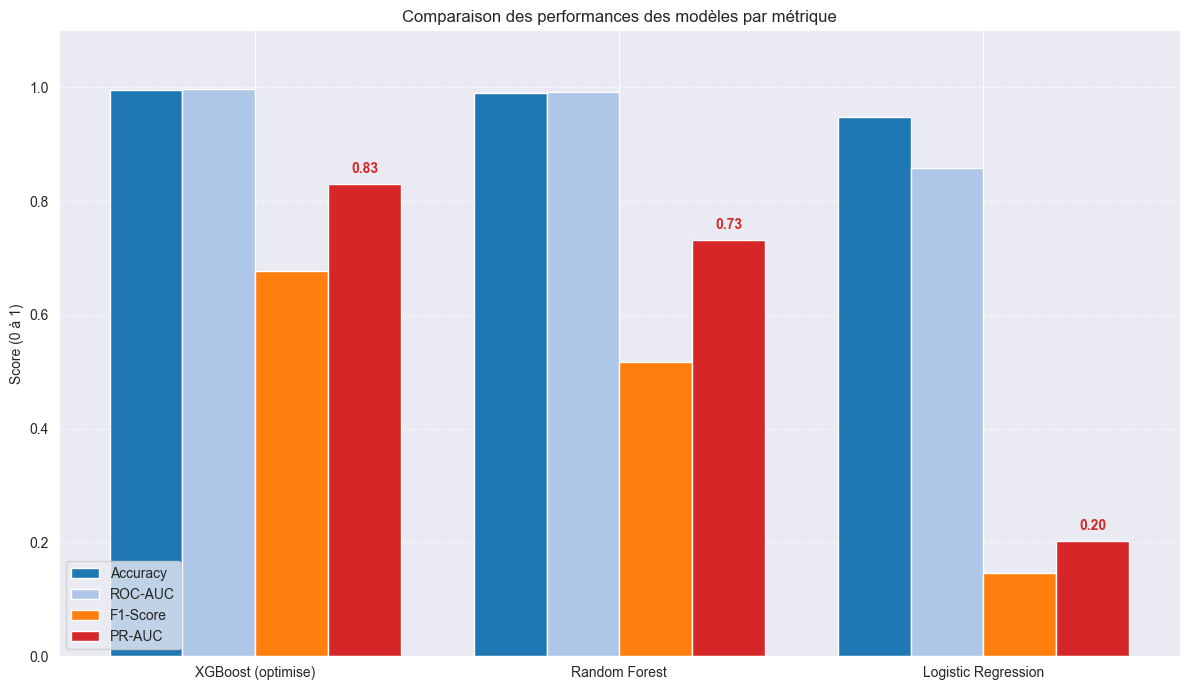

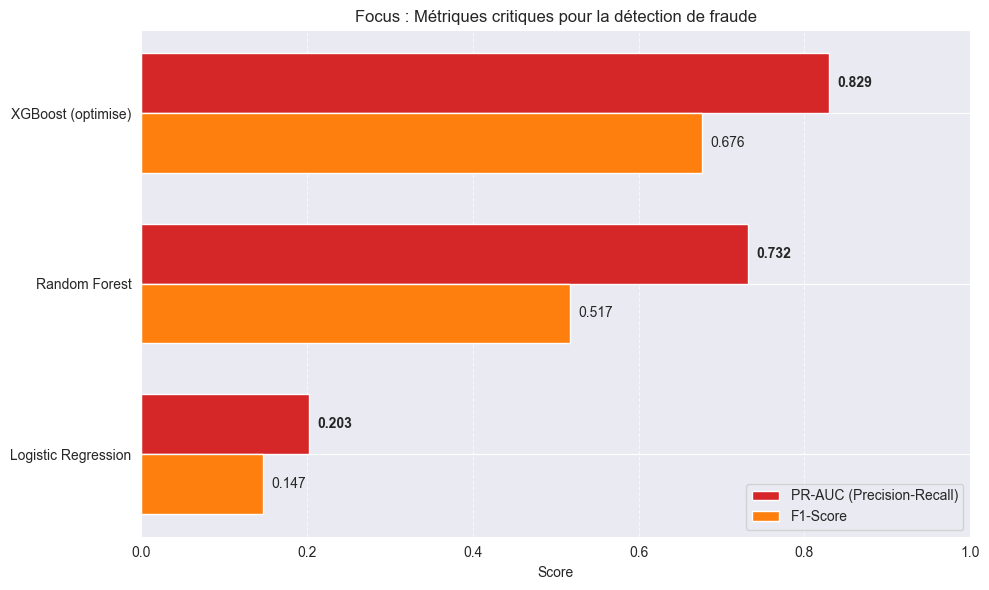

In [142]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Préparation des donnée

df = pd.DataFrame(resultats)

# --- GRAPHIQUE 1 : COMPARAISON GLOBALE ---
plt.figure(figsize=(12, 7))
x = np.arange(len(df['Modele']))
width = 0.2  # Largeur des barres

# Création des barres pour chaque métrique
plt.bar(x - 1.5*width, df['Accuracy'], width, label='Accuracy', color='#1f77b4')
plt.bar(x - 0.5*width, df['ROC-AUC'], width, label='ROC-AUC', color='#aec7e8')
plt.bar(x + 0.5*width, df['F1-Score'], width, label='F1-Score', color='#ff7f0e')
plt.bar(x + 1.5*width, df['PR-AUC'], width, label='PR-AUC', color='#d62728')

# Mise en forme
plt.ylabel('Score (0 à 1)')
plt.title('Comparaison des performances des modèles par métrique')
plt.xticks(x, df['Modele'])
plt.legend(loc='lower left')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajout des valeurs au-dessus des barres PR-AUC (la plus importante)
for i in range(len(x)):
    plt.text(x[i] + 1.5*width, df['PR-AUC'][i] + 0.02, f"{df['PR-AUC'][i]:.2f}",
             ha='center', fontweight='bold', color='#d62728')

plt.tight_layout()
plt.show()


# --- GRAPHIQUE 2 : FOCUS FRAUDE (PR-AUC & F1) ---
plt.figure(figsize=(10, 6))
# On trie pour avoir le meilleur en haut
df_focus = df[['Modele', 'F1-Score', 'PR-AUC']].sort_values(by='PR-AUC', ascending=True)

y = np.arange(len(df_focus['Modele']))
height = 0.35

plt.barh(y + height/2, df_focus['PR-AUC'], height, label='PR-AUC (Precision-Recall)', color='#d62728')
plt.barh(y - height/2, df_focus['F1-Score'], height, label='F1-Score', color='#ff7f0e')

# Mise en forme
plt.xlabel('Score')
plt.title('Focus : Métriques critiques pour la détection de fraude')
plt.yticks(y, df_focus['Modele'])
plt.legend()
plt.xlim(0, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Ajout des étiquettes de données
for i, val in enumerate(df_focus['PR-AUC']):
    plt.text(val + 0.01, i + height/2, f"{val:.3f}", va='center', fontweight='bold')
for i, val in enumerate(df_focus['F1-Score']):
    plt.text(val + 0.01, i - height/2, f"{val:.3f}", va='center')

plt.tight_layout()
plt.show()

Le meilleure modèle est le XGBoost, il permet de garder une bonne harmonie entre recall, precision et F1-Score